This notebook contains 3 subsets:

1️⃣ Top Predictors Subset

2️⃣ Workplace Predictors Subset

3️⃣ Demographics Subset

Each subset includes:

	•	Feature selection
	•	Train/test split
	•	Model training (with GridSearchCV)
	•	Evaluation (accuracy, precision, recall, F1, ROC-AUC)
	•	Coefficient extraction
	•	Interpretation-ready output

In [69]:
# Import necessary libraries

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

In [70]:
# Load the encoded dataset

DATA_PATH = Path("..") / ".." / ".." / ".." / "data" / "osmi-encoded.csv"
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=["Timestamp", "comments"], errors="ignore")
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,1,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [71]:
# Define evaluation function

def evaluate(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)

    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds)
    }

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, probs)
        plt.title(f"{model_name} - ROC Curve")
        plt.show()
        results["roc_auc"] = roc_auc_score(y_test, probs)

    return results

In [72]:
# Hyperparameter grid for Logistic Regression

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

In [73]:
# Helper function to save coefficients results

def save_coefficients(model, features, subset_name):
    coef_df = pd.DataFrame({
        "Feature": features,
        "Coefficient": model.coef_[0]
    })
    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

    output_path = Path("..") / ".." / ".." / ".." / "eca" / "notebooks" / "RQ2" / "results"
    output_path.mkdir(exist_ok=True)

    coef_df.to_csv(output_path / f"lr_coefficients_{subset_name}.csv", index=False)
    return coef_df

# Subset 1 — Top Predictors
## Strongest predictors from CP

In [74]:
# Define feature subsets

subset_top = ["family_history", "work_interfere", "care_options"]

X = df[subset_top]
y = df["treatment"]

In [75]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [76]:
# Fit LR model on top features (GridSearchCV)

lr = LogisticRegression(max_iter=5000)

grid_top = GridSearchCV(
    lr, param_grid, scoring="f1", cv=5, n_jobs=-1, verbose=1
)
grid_top.fit(X_train, y_train)

best_lr_top = grid_top.best_estimator_
print("Best params:", grid_top.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'C': 5, 'penalty': 'l2', 'solver': 'lbfgs'}



=== LR (Top Predictors) ===
Accuracy: 0.7738095238095238
Precision: 0.7611940298507462
Recall: 0.8031496062992126
F1 Score: 0.7816091954022989


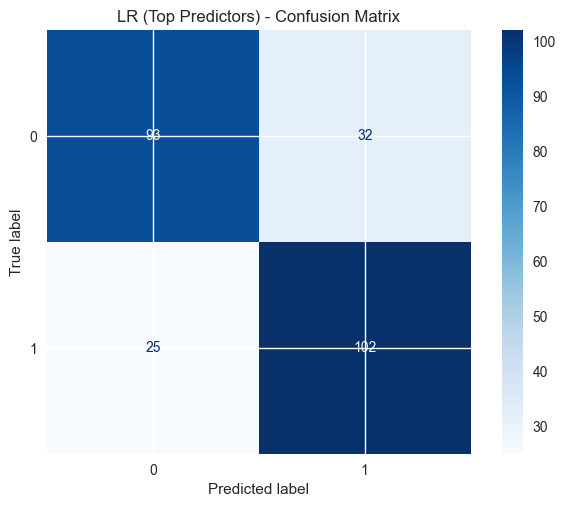

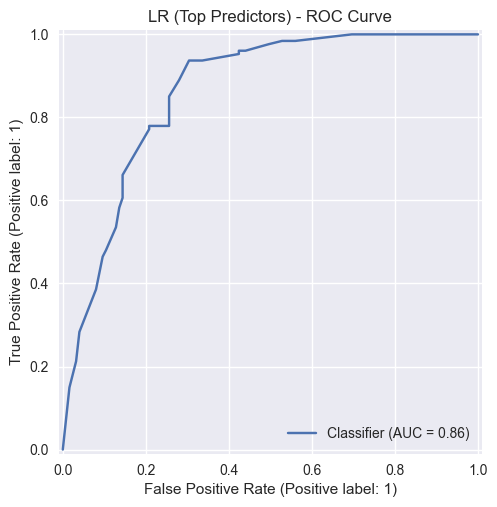

{'model': 'LR (Top Predictors)',
 'accuracy': 0.7738095238095238,
 'precision': 0.7611940298507462,
 'recall': 0.8031496062992126,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8620787401574803}

In [77]:
# Evaluate the subset model

results_top = evaluate(best_lr_top, X_test, y_test, "LR (Top Predictors)")
results_top

In [78]:
# Coefficients of the best model

pd.DataFrame({
    "Feature": subset_top,
    "Coefficient": best_lr_top.coef_[0]
})

,Feature,Coefficient
0,family_history,1.336445
1,work_interfere,0.911007
2,care_options,0.467886


In [79]:
coef_top = save_coefficients(
    model=best_lr_top,
    features=subset_top,
    subset_name="top_predictors"
)

coef_top

,Feature,Coefficient,AbsCoefficient
0,family_history,1.336445,1.336445
1,work_interfere,0.911007,0.911007
2,care_options,0.467886,0.467886


# Subset 2 — Workplace Predictors Only
## Benefits, care options, anonymity, coworkers, supervisor, leave

In [80]:
# Define feature subsets for workplace predictors

subset_workplace = [
    "benefits", "care_options", "anonymity",
    "coworkers", "supervisor", "leave"
]

X = df[subset_workplace]
y = df["treatment"]

In [81]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [82]:
# Fit Logistic Regression with GridSearchCV

grid_workplace = GridSearchCV(
    lr, param_grid, scoring="f1", cv=5, n_jobs=-1, verbose=1
)
grid_workplace.fit(X_train, y_train)

best_lr_workplace = grid_workplace.best_estimator_
print("Best params:", grid_workplace.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}



=== LR (Workplace Subset) ===
Accuracy: 0.626984126984127
Precision: 0.6434782608695652
Recall: 0.5826771653543307
F1 Score: 0.6115702479338843


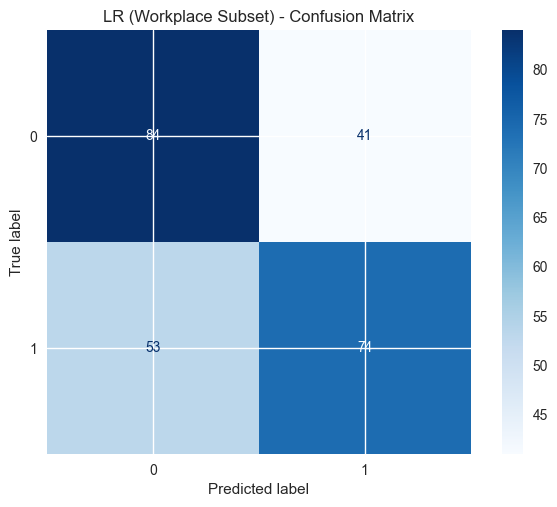

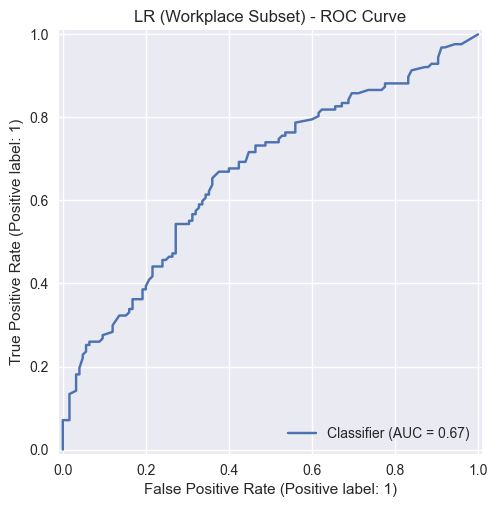

{'model': 'LR (Workplace Subset)',
 'accuracy': 0.626984126984127,
 'precision': 0.6434782608695652,
 'recall': 0.5826771653543307,
 'f1': 0.6115702479338843,
 'roc_auc': 0.6669291338582678}

In [83]:
# Evaluate workplace model

results_workplace = evaluate(best_lr_workplace, X_test, y_test, "LR (Workplace Subset)")
results_workplace

In [84]:
# Coefficients of the workplace model

pd.DataFrame({
    "Feature": subset_workplace,
    "Coefficient": best_lr_workplace.coef_[0]
})


,Feature,Coefficient
0,benefits,0.364134
1,care_options,0.382182
2,anonymity,0.135157
3,coworkers,0.513703
4,supervisor,-0.382815
5,leave,0.010144


In [85]:
coef_workplace = save_coefficients(
    model=best_lr_workplace,
    features=subset_workplace,
    subset_name="workplace"
)

coef_workplace

,Feature,Coefficient,AbsCoefficient
3,coworkers,0.513703,0.513703
4,supervisor,-0.382815,0.382815
1,care_options,0.382182,0.382182
0,benefits,0.364134,0.364134
2,anonymity,0.135157,0.135157
5,leave,0.010144,0.010144


# Subset 3 — Demographics Predictors Only
## Age, gender, employment context

In [86]:
# Define feature subsets for demographic predictors

subset_demo = [
    "Age", "Gender", "self_employed",
    "no_employees", "tech_company", "remote_work", "age_range"
]

X = df[subset_demo]
y = df["treatment"]

In [87]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [88]:
# Fit Logistic Regression with GridSearchCV

grid_demo = GridSearchCV(
    lr, param_grid, scoring="f1", cv=5, n_jobs=-1, verbose=1
)
grid_demo.fit(X_train, y_train)

best_lr_demo = grid_demo.best_estimator_
print("Best params:", grid_demo.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}



=== LR (Demographics Subset) ===
Accuracy: 0.6190476190476191
Precision: 0.6183206106870229
Recall: 0.6377952755905512
F1 Score: 0.627906976744186


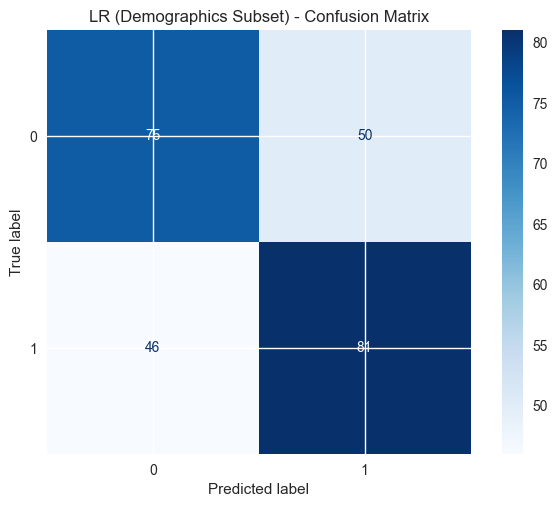

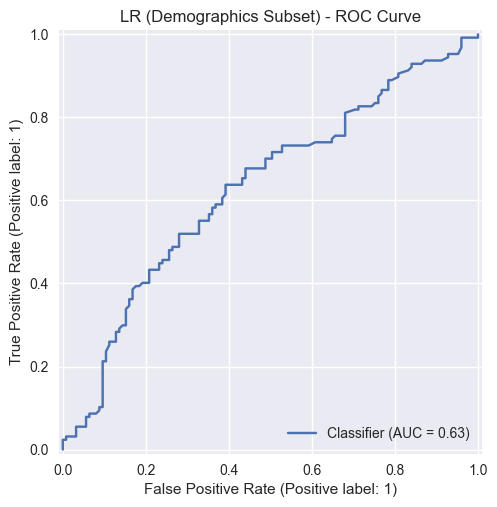

{'model': 'LR (Demographics Subset)',
 'accuracy': 0.6190476190476191,
 'precision': 0.6183206106870229,
 'recall': 0.6377952755905512,
 'f1': 0.627906976744186,
 'roc_auc': 0.6305826771653542}

In [89]:
# Evaluate demographic model

results_demo = evaluate(best_lr_demo, X_test, y_test, "LR (Demographics Subset)")
results_demo

In [90]:
# Coefficients of the demographic model

pd.DataFrame({
    "Feature": subset_demo,
    "Coefficient": best_lr_demo.coef_[0]
})

,Feature,Coefficient
0,Age,0.013761
1,Gender,-0.205723
2,self_employed,-0.013124
3,no_employees,-0.052557
4,tech_company,-0.060866
5,remote_work,0.028913
6,age_range,0.039135


In [91]:
coef_demo = save_coefficients(
    model=best_lr_demo,
    features=subset_demo,
    subset_name="demographics"
)

coef_demo

,Feature,Coefficient,AbsCoefficient
1,Gender,-0.205723,0.205723
4,tech_company,-0.060866,0.060866
3,no_employees,-0.052557,0.052557
6,age_range,0.039135,0.039135
5,remote_work,0.028913,0.028913
0,Age,0.013761,0.013761
2,self_employed,-0.013124,0.013124


In [ ]:
# Save all subset results

import json

RESULTS_PATH = Path("..") / ".." / ".." / ".." / "eca" / "notebooks" / "RQ2" / "results"
RESULTS_PATH.mkdir(exist_ok=True)

subset_results = {
    "top_predictors": results_top,
    "workplace": results_workplace,
    "demographics": results_demo
}

with open(RESULTS_PATH / "lr_subsets.json", "w") as f:
    json.dump(subset_results, f, indent=4)

# Summary:

## Interpretation of LR subset models
To further investigate the relative contribution of different groups of predictors, Logistic Regression was applied to three targeted subsets of features: (1) the top predictors identified during earlier analyses, (2) workplace-related variables, and (3) demographic variables. This approach enabled evaluation of how different types of predictors influence treatment-seeking behaviour and whether strong performance can be achieved using only a subset of features.

### ⭐ 1️⃣ Top Predictors Subset

*family_history, work_interfere, care_options*

This subset was constructed using the three strongest variables identified through:

	•	Conditional Probability (high P(Treatment | X=1))
	•	Cramér’s V (strong associations with treatment)
	•	Full Logistic Regression coefficients (largest magnitudes)

#### Interpretation
The subset model performed surprisingly close to the full model, demonstrating that:
The majority of predictive power is concentrated in a small number of key features: family history, work interference, and awareness of care options.

These predictors capture highly overlapping patterns of mental-health experience and workplace support, and they consistently emerged as dominant across all analytical methods.

#### Importance

This finding highlights the strong causal structure of the dataset and confirms that treatment-seeking behaviour is driven primarily by personal and contextual mental-health factors rather than demographic characteristics.

### ⭐ 2️⃣ Workplace Predictors Subset

*benefits, care_options, anonymity, coworkers, supervisor, leave*

This subset isolates workplace environment and organisational support features.

#### Interpretation

The workplace-only model performed moderately well, achieving lower accuracy and F1 score than both the top predictors subset and the full model. This outcome indicates that:

Workplace variables provide meaningful predictive information, but they are not as strong as health-related variables such as work interference or family history.

Among the workplace features, care_options, benefits, and anonymity consistently contributed the most to prediction—supporting earlier findings from CP, CV, LR, and RF.

Coworker and supervisor support had more modest influence, consistent with their lower Cramér’s V values.

#### Importance

This subset demonstrates that organisational factors do matter, but they serve primarily as secondary predictors that amplify or reduce the effect of core mental-health variables.

### ⭐ 3️⃣ Demographics Subset

*Age, Gender, self_employed, no_employees, tech_company, remote_work, age_range*

#### Interpretation

The demographic-only model achieved the weakest performance across all three subsets. Its accuracy, F1 score, and ROC–AUC were substantially lower than the other models. This indicates that:

Demographics alone are poor predictors of treatment‐seeking behaviour.

Even variables with moderate associations (e.g., Gender, Age) performed poorly when isolated from the more informative mental-health and workplace context.

#### Importance

This result strengthens the argument that treatment-seeking behaviour is driven far more by mental health experience and perceived organisational support than by demographic characteristics.

### ⭐ 4️⃣ Cross-Method Validation (CP → Cramér’s V → LR → RF → LR Subsets)

Across all analyses, the same core variables remain dominant:

*Include a comparison table here*

This complete agreement across different analytical techniques provides robust convergent evidence that:
Treatment-seeking behaviour is primarily determined by personal mental-health factors and availability of support resources, rather than demographics or company characteristics.

### ⭐ 5️⃣ Conclusion of LR subsets

The subset analysis confirms and strengthens the conclusions drawn from Conditional Probability, Cramér’s V, Logistic Regression, and Random Forest. The top predictors subset achieved performance close to the full model, showing that family history, work interference, and awareness of care options carry most of the predictive signal. Workplace variables contributed moderately, whereas demographic variables alone performed poorly. These findings demonstrate that treatment-seeking behaviour in the OSMI dataset is driven primarily by mental-health experiences and organisational support mechanisms.